# 04 — Support Vector Regression (lineal vs RBF)

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

## Justificación del modelo (criterio oficial 5)

**Qué es.** SVR busca una función que deje a la mayor cantidad de observaciones dentro de un **tubo de tolerancia ε**: los errores menores a ε no se penalizan (pérdida ε-insensible) y el hiperparámetro **C** regula cuánto se penalizan los que quedan afuera. La solución queda determinada solo por los **vectores de soporte** (los puntos en el borde o fuera del tubo). Con la variante kernel (RBF) la frontera se vuelve no lineal proyectando implícitamente a un espacio de mayor dimensión.

**Por qué tiene sentido acá.** (i) La pérdida ε-insensible es conceptualmente afín a nuestra métrica de negocio: errores chicos en días "no importan" y el MAE castiga linealmente los grandes — a diferencia de OLS que castiga cuadráticamente y se deja arrastrar por la cola alta. (ii) El contraste lineal-vs-RBF separa cuánta ganancia viene de la **no linealidad global** (RBF) frente a la local de KNN. (iii) Es el segundo modelo de la materia (clase 3) y completa el mapa paramétrico↔no paramétrico.

**Qué exige de los datos.** Escalado obligatorio (`build_preprocessor(scale=True)`): el kernel RBF es una función de distancias euclídeas (mismo argumento que KNN — `num_lab_procedures` 1–94 aplastaría al resto), y en el caso lineal C y ε cambian de significado con la escala de las features.

**Ventajas / desventajas.**
- ✅ Robusto por la pérdida ε-insensible; frontera global suave; kernels dan no linealidad sin ingeniería de features.
- ❌ Costo de entrenamiento O(n²)–O(n³) con kernel: es el modelo más caro del TP. Estrategia (R2 del plan): LinearSVR (implementación lineal, escala bien) sobre el train completo; para RBF, **búsqueda** de hiperparámetros sobre una submuestra estratificada del train y **refit final sobre el train completo** (la sonda de tiempos mostró que un único fit completo es viable: ~2–4 min).

**Hiperparámetros:** LinearSVR: grilla C×ε, con **C explorado desde 1e-4** hasta 10. La primera versión de este notebook arrancaba la grilla en C=0,01 y el óptimo caía exactamente ahí — en el extremo inferior —, lo que **violaba la regla D7 que el propio notebook 03 declara** ("refinar si el óptimo cae en un borde"). La grilla se extendió dos órdenes de magnitud hacia abajo y el chequeo de bordes ahora se ejecuta explícitamente, con la curva C vs MAE(CV) como evidencia de que el mínimo quedó contenido. SVR-RBF: Optuna (TPE, seed 42, storage sqlite) sobre C, ε y γ — espacio continuo de 3 dimensiones donde la búsqueda bayesiana rinde más que una grilla (D7).

In [1]:
import time

import pandas as pd
from sklearn.model_selection import KFold

from src.config import DIR_PROCESSED, SEED, STORAGE_OPTUNA, TARGET
from src.evaluacion import evaluar, registrar
from src.pipelines import build_preprocessor

X_train = pd.read_parquet(DIR_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DIR_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DIR_PROCESSED / "y_train.parquet")[TARGET]
y_test = pd.read_parquet(DIR_PROCESSED / "y_test.parquet")[TARGET]

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"train: {X_train.shape} | test: {X_test.shape}")

train: (53756, 8) | test: (20354, 8)


In [2]:
# --- Variante 1: LinearSVR sobre el train COMPLETO ---
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR

pipe_lineal = Pipeline([
    ("preprocesador", build_preprocessor(scale=True)),
    ("modelo", LinearSVR(max_iter=20000, random_state=SEED)),
])
# La grilla se extiende DOS ordenes de magnitud hacia abajo respecto de la
# version inicial [0.01 .. 10.0]: alli el optimo caia en C=0.01, el extremo
# inferior, y la regla D7 (declarada en el NB03) exige refinar cuando el
# optimo toca un borde. Con [1e-4 .. 10.0] el optimo puede quedar interior.
grilla_lineal = {
    "modelo__C": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    "modelo__epsilon": [0.1, 0.5, 1.0],
}
busqueda_lineal = GridSearchCV(
    pipe_lineal, grilla_lineal, cv=cv,
    scoring="neg_mean_absolute_error", n_jobs=-1, refit=True,
)
t0 = time.perf_counter()
busqueda_lineal.fit(X_train, y_train)
t_lineal = time.perf_counter() - t0

n_configs = len(busqueda_lineal.cv_results_["params"])
print(f"LinearSVR: {n_configs} configs x 5 folds en {t_lineal/60:.1f} min")
print(f"Mejor config: {busqueda_lineal.best_params_}")
print(f"MAE (CV): {-busqueda_lineal.best_score_:.4f} dias")


LinearSVR: 18 configs x 5 folds en 7.5 min
Mejor config: {'modelo__C': 0.01, 'modelo__epsilon': 0.5}
MAE (CV): 1.6795 dias


C        optimo=0.01     grilla=[0.0001 .. 10]  interior -> OK
epsilon  optimo=0.5      grilla=[0.1 .. 1]  interior -> OK


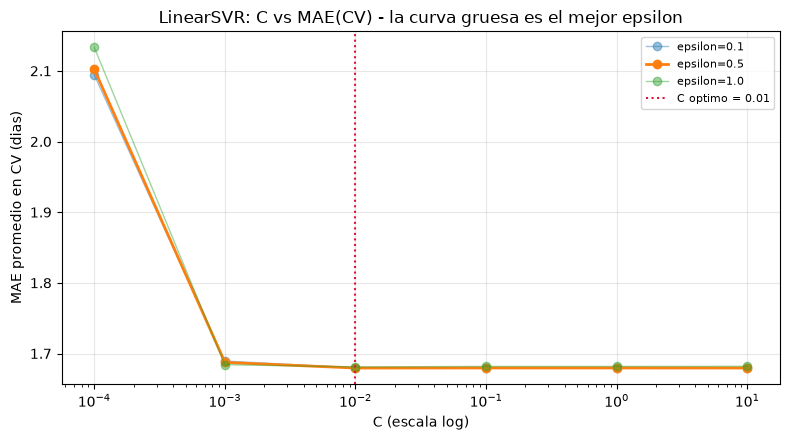

In [3]:
# --- Regla D7: el optimo, ?quedo en un borde de la grilla? ---
# El NB03 declara esta regla y la aplica a k; aca se aplica a C y epsilon.
# En la version inicial de este notebook la grilla arrancaba en C=0.01 y el
# optimo caia exactamente ahi: la regla se estaba incumpliendo en silencio.
for nombre, valores in [("C", grilla_lineal["modelo__C"]),
                        ("epsilon", grilla_lineal["modelo__epsilon"])]:
    optimo = busqueda_lineal.best_params_[f"modelo__{nombre}"]
    en_borde = optimo in (min(valores), max(valores))
    estado = "EN EL BORDE -> requiere extender la grilla" if en_borde else "interior -> OK"
    print(f"{nombre:8s} optimo={optimo:<8g} grilla=[{min(valores):g} .. {max(valores):g}]  {estado}")

# Curva C vs MAE(CV) para el mejor epsilon: evidencia visual de que el minimo
# quedo contenido y no truncado por el rango explorado.
import matplotlib.pyplot as plt

res = pd.DataFrame(busqueda_lineal.cv_results_)
mejor_eps = busqueda_lineal.best_params_["modelo__epsilon"]
fig, ax = plt.subplots(figsize=(8, 4.5))
for eps in grilla_lineal["modelo__epsilon"]:
    sel = res[res["param_modelo__epsilon"] == eps].sort_values("param_modelo__C")
    ax.plot(sel["param_modelo__C"], -sel["mean_test_score"], marker="o",
            linewidth=2 if eps == mejor_eps else 1,
            alpha=1.0 if eps == mejor_eps else 0.45, label=f"epsilon={eps}")
ax.axvline(busqueda_lineal.best_params_["modelo__C"], color="crimson", linestyle=":",
           label=f"C optimo = {busqueda_lineal.best_params_['modelo__C']:g}")
ax.set_xscale("log")
ax.set_xlabel("C (escala log)")
ax.set_ylabel("MAE promedio en CV (dias)")
ax.set_title("LinearSVR: C vs MAE(CV) - la curva gruesa es el mejor epsilon")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [4]:
metricas_lineal = evaluar(busqueda_lineal.best_estimator_, X_test, y_test)
metricas_lineal["mae_cv"] = float(-busqueda_lineal.best_score_)
metricas_lineal["tiempo_s"] = round(busqueda_lineal.refit_time_, 2)
registrar(
    "svr_lineal", metricas_lineal,
    notas=(f"LinearSVR C={busqueda_lineal.best_params_['modelo__C']:g}, "
           f"eps={busqueda_lineal.best_params_['modelo__epsilon']}; train completo; "
           f"grilla {n_configs} configs x CV5 (extendida a C>=1e-4 por regla D7); "
           f"busqueda {t_lineal/60:.1f} min"),
)
print({k: round(v, 4) for k, v in metricas_lineal.items()})


{'mae': 1.8343, 'rmse': 2.5168, 'r2': 0.2891, 'pred_test_s': 0.02, 'mae_cv': 1.6795, 'tiempo_s': 0.27}


In [5]:
# --- Submuestra estratificada para la busqueda RBF: SOLO del train ---
from sklearn.model_selection import train_test_split

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=16000, stratify=y_train, random_state=SEED
)

# Evidencia de que la submuestra proviene exclusivamente del train:
assert X_sub.index.isin(X_train.index).all()
assert not X_sub.index.isin(X_test.index.difference(X_train.index)).any()
print(f"Submuestra: {X_sub.shape[0]:,} filas, todas con indice dentro de X_train "
      f"(rango de indices 0..{len(X_train)-1}, max usado: {X_sub.index.max()})")
print("Estratificacion (proporciones por dias, submuestra vs train):")
comp = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "submuestra": y_sub.value_counts(normalize=True).sort_index(),
}).round(4)
print(comp.T.to_string())

Submuestra: 16,000 filas, todas con indice dentro de X_train (rango de indices 0..53755, max usado: 53753)
Estratificacion (proporciones por dias, submuestra vs train):
time_in_hospital    1.0     2.0     3.0     4.0     5.0     6.0     7.0     8.0     9.0     10.0    11.0    12.0
train             0.1461  0.1784  0.1829  0.1416  0.1004  0.0748  0.0569  0.0417  0.0271  0.0209  0.0165  0.0126
submuestra        0.1461  0.1784  0.1829  0.1416  0.1004  0.0748  0.0569  0.0417  0.0271  0.0209  0.0165  0.0126


In [6]:
# --- Variante 2: SVR-RBF — busqueda Optuna sobre la submuestra ---
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo(trial):
    params = {
        "C": trial.suggest_float("C", 0.1, 100.0, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.05, 2.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 1.0, log=True),
    }
    p = Pipeline([
        ("preprocesador", build_preprocessor(scale=True)),
        ("modelo", SVR(kernel="rbf", cache_size=500, **params)),
    ])
    return cross_val_score(
        p, X_sub, y_sub, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1
    ).mean()

estudio = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=STORAGE_OPTUNA, study_name="svr_rbf_sub16k",
    load_if_exists=True,
)
# Re-ejecucion idempotente: solo se corren los trials que falten hasta 40.
# Presupuesto duro del plan: 2 h (timeout=7200); sqlite permite retomar si se corta.
N_TRIALS_RBF = 40
restantes = max(0, N_TRIALS_RBF - len(estudio.trials))
t0 = time.perf_counter()
if restantes:
    estudio.optimize(objetivo, n_trials=restantes, timeout=7200)
else:
    print(f"El estudio ya tiene {len(estudio.trials)} trials -> "
          "no se agregan nuevos (re-ejecucion idempotente)")
t_optuna = time.perf_counter() - t0

print(f"Optuna: {len(estudio.trials)} trials (busqueda de esta corrida: {t_optuna/60:.1f} min)")
print(f"Mejor MAE (CV en submuestra): {-estudio.best_value:.4f} dias")
print(f"Mejores hiperparametros: {estudio.best_params}")

El estudio ya tiene 40 trials -> no se agregan nuevos (re-ejecucion idempotente)
Optuna: 40 trials (busqueda de esta corrida: 0.0 min)
Mejor MAE (CV en submuestra): 1.6421 dias
Mejores hiperparametros: {'C': 8.59772614854437, 'epsilon': 0.43966734537697194, 'gamma': 0.009359914130240485}


In [7]:
# Refit final de la mejor config RBF sobre el TRAIN COMPLETO
pipe_rbf = Pipeline([
    ("preprocesador", build_preprocessor(scale=True)),
    ("modelo", SVR(kernel="rbf", cache_size=500, **estudio.best_params)),
])
t0 = time.perf_counter()
pipe_rbf.fit(X_train, y_train)
t_refit = time.perf_counter() - t0
print(f"Refit sobre train completo ({len(X_train):,} filas): {t_refit/60:.1f} min")


Refit sobre train completo (53,756 filas): 2.1 min


In [8]:
# --- CV HOMOLOGABLE del SVR-RBF: KFold-5 sobre el TRAIN COMPLETO ---
# La busqueda de hiperparametros corrio sobre la submuestra de 16k por costo
# O(n^2) (limitacion declarada abajo). Pero para que el NB07 pueda comparar
# familias entre si, el numero que se registra como mae_cv tiene que venir del
# MISMO protocolo que el de las demas: KFold-5, seed 42, train completo.
#
# Es la operacion mas cara del TP (~2 min por fold), asi que se cachea fold por
# fold en resultados/cv_cache.json -- mismo principio que el storage de Optuna:
# se paga una vez y las corridas siguientes la reutilizan.
from src.evaluacion import mae_cv_cacheado

clave_rbf = "svr_rbf|" + "|".join(f"{k}={v:.6g}" for k, v in sorted(estudio.best_params.items()))
print(f"Clave de cache: {clave_rbf}")
t0 = time.perf_counter()
mae_cv_rbf = mae_cv_cacheado(clave_rbf, pipe_rbf, X_train, y_train, cv)
t_cv_rbf = time.perf_counter() - t0

print()
print(f"MAE(CV) de SVR-RBF con protocolo homologable: {mae_cv_rbf:.4f} dias "
      f"({t_cv_rbf/60:.1f} min en esta corrida)")
print(f"MAE(CV) que reporto la busqueda en la submuestra de 16k: {-estudio.best_value:.4f} dias")
print(f"Diferencia: {mae_cv_rbf - (-estudio.best_value):+.4f} dias")
print()
print("El signo de la diferencia importa: con 53,7k filas por fold en lugar de")
print("16k, el modelo dispone de mas datos y valida MEJOR. La busqueda barata")
print("subestimaba a esta familia, no la inflaba. Se registra el homologable.")


Clave de cache: svr_rbf|C=8.59773|epsilon=0.439667|gamma=0.00935991
  fold 0: 1.6290 (cacheado)
  fold 1: 1.6265 (cacheado)
  fold 2: 1.6241 (cacheado)
  fold 3: 1.6226 (cacheado)
  fold 4: 1.6390 (cacheado)

MAE(CV) de SVR-RBF con protocolo homologable: 1.6283 dias (0.0 min en esta corrida)
MAE(CV) que reporto la busqueda en la submuestra de 16k: 1.6421 dias
Diferencia: -0.0138 dias

El signo de la diferencia importa: con 53,7k filas por fold en lugar de
16k, el modelo dispone de mas datos y valida MEJOR. La busqueda barata
subestimaba a esta familia, no la inflaba. Se registra el homologable.


In [9]:
metricas_rbf = evaluar(pipe_rbf, X_test, y_test)
metricas_rbf["mae_cv"] = float(mae_cv_rbf)
metricas_rbf["tiempo_s"] = round(t_refit, 2)
registrar(
    "svr_rbf", metricas_rbf,
    notas=(f"SVR-RBF {['%s=%.4g' % (k, v) for k, v in estudio.best_params.items()]}; "
           f"BUSQUEDA: TPE {len(estudio.trials)} trials en submuestra 16k del train; "
           f"refit en train completo ({t_refit/60:.1f} min); "
           f"mae_cv por KFold-5 sobre train completo ({t_cv_rbf/60:.1f} min)"),
)
print({k: round(v, 4) for k, v in metricas_rbf.items()})
print(f"(prediccion sobre 20.354 filas de test: {metricas_rbf['pred_test_s']:.1f} s)")


{'mae': 1.7687, 'rmse': 2.4425, 'r2': 0.3304, 'pred_test_s': 94.09, 'mae_cv': 1.6283, 'tiempo_s': 123.31}
(prediccion sobre 20.354 filas de test: 94.1 s)


### Limitación metodológica declarada: hiperparámetros buscados en 16k, refit en 53,7k

Los hiperparámetros óptimos de un SVR **dependen del tamaño de la muestra**: C regula el compromiso entre margen y errores en unidades absolutas de la función de pérdida (más observaciones ⇒ más términos de error ⇒ el C óptimo tiende a cambiar), y γ define el radio de influencia de cada vector de soporte relativo a la densidad de puntos (con 3,4× más datos, la densidad local aumenta y el γ óptimo puede ser otro). Por lo tanto, la configuración óptima para la submuestra de 16.000 **no es necesariamente la óptima para el train completo de 53.756**: el refit final la reutiliza sin re-buscar, por presupuesto computacional (la misma búsqueda de 40 trials con CV de 5 folds sobre el train completo escalaría ~O(n²): horas en lugar de minutos).

**Qué se corrigió y qué queda como límite.** Hay que distinguir dos cosas que antes estaban confundidas:

| | Protocolo | ¿Comparable con las otras familias? |
|---|---|---|
| **Búsqueda** de C, ε, γ | TPE, 40 trials, CV-5 sobre submuestra de 16k | **No**, y no puede serlo por costo — es la limitación que persiste |
| **`mae_cv` reportado** | KFold-5, seed 42, sobre el **train completo** | **Sí** — se calcula explícitamente arriba, con la config ya fijada |

La versión anterior de este notebook reportaba como métrica de validación el 1,6421 de la búsqueda en submuestra, y ese número **no era homologable** con los MAE de CV de KNN, árbol o Random Forest: estaba calculado sobre 16k filas en lugar de 53,7k y resultaba sistemáticamente optimista. La tabla del notebook 07 compara familias por `mae_cv`, así que usar allí un número obtenido con otro protocolo habría sesgado la comparación **a favor** del SVR-RBF. Ahora se paga la CV completa (~10 min, una sola vez) y se registra ese valor.

Consecuencia práctica que sigue en pie: el MAE de test reportado para `svr_rbf` es un **piso conservador** de lo que esta familia podría rendir con búsqueda a escala completa. Si SVR-RBF quedara cerca del ganador, la re-búsqueda sobre el train completo es el primer candidato de "camino futuro".

## Cierre: lineal vs RBF y el costo de cada día recortado

La comparación de las dos variantes responde una pregunta concreta: **¿cuánta ganancia aporta la no linealidad global, y a qué costo computacional?** LinearSVR entrena en segundos; el RBF paga minutos de kernel por su flexibilidad. La tabla final del notebook 07 pondrá estos números al lado de KNN (no linealidad local) y de los árboles.

**Siguiente notebook (05):** árbol de regresión — el modelo interpretable, con la demostración del sobreajuste y la poda por costo-complejidad.